In [24]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast
import seaborn as sns



#Load the dataset
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()



In [25]:
#Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

def clean_skills(x):
    if isinstance(x, list):
        return x
    elif pd.isna(x):
        return []
    elif isinstance(x, str):
        return ast.literal_eval(x)
    else:
        return []

df["job_skills_clean"] = df["job_skills"].apply(clean_skills)

skills_df = df[["job_title_short","job_country", "job_work_from_home","job_posted_date","job_skills_clean"]].copy()
skills_df = skills_df.explode('job_skills_clean')
skills_df = skills_df.rename(columns={'job_skills_clean':'skill'})
skills_df = skills_df.dropna(subset=["skill"])
skills_df['skill'] = skills_df['skill'].str.lower().str.strip()

In [26]:
# Filter to top roles
top_roles = [ "Data Analyst","Data Engineer","Data Scientist"]


df_top_roles = df[df["job_title_short"].isin(top_roles)].copy()
skills_top_roles = skills_df[skills_df["job_title_short"].isin(top_roles)].copy()

In [27]:
remote_by_role = (df_top_roles.groupby("job_title_short")["job_work_from_home"].mean().sort_values(ascending=False).mul(100))

In [28]:
remote_by_role

job_title_short
Data Engineer     11.389007
Data Scientist     8.436553
Data Analyst       6.796379
Name: job_work_from_home, dtype: float64

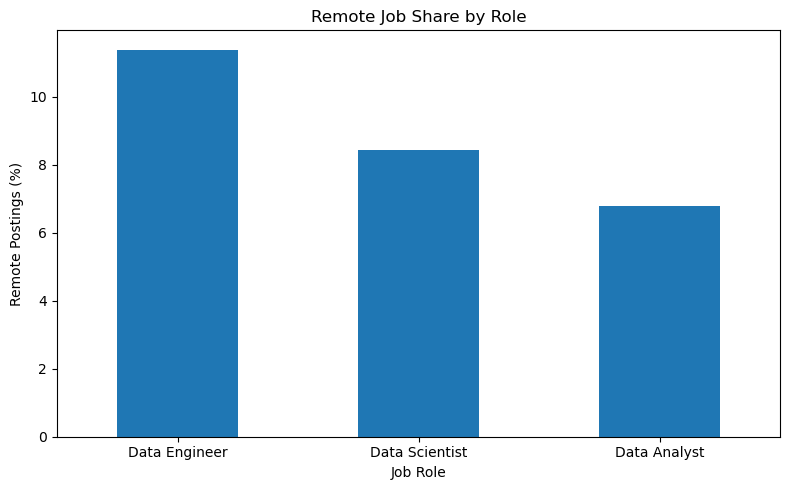

In [29]:
# Visualization: remote rate by role
plt.figure(figsize=(8, 5))

remote_by_role.plot(kind="bar")

plt.title("Remote Job Share by Role")
plt.xlabel("Job Role")
plt.ylabel("Remote Postings (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [30]:
# Count skills by remote status
remote_skill_counts = (skills_top_roles.groupby(["job_work_from_home", "skill"]).size().reset_index(name="count"))

# Normalize within remote / non-remote groups
remote_totals = (skills_top_roles.groupby("job_work_from_home").size().reset_index(name="total"))

remote_skill_counts = remote_skill_counts.merge(remote_totals,on="job_work_from_home")

remote_skill_counts["pct"] = (remote_skill_counts["count"] / remote_skill_counts["total"])

remote_skill_counts

,job_work_from_home,skill,count,total,pct
0,False,airflow,26414,2310787,0.011431
1,False,airtable,188,2310787,0.000081
2,False,alteryx,8327,2310787,0.003604
3,False,angular,2365,2310787,0.001023
4,False,angular.js,52,2310787,0.000023
...,...,...,...,...,...
478,True,wrike,5,258726,0.000019
479,True,wsl,3,258726,0.000012
480,True,xamarin,5,258726,0.000019
481,True,yarn,159,258726,0.000615


In [31]:
# Pivot remote vs non-remote skill frequencies
remote_skill_pivot = remote_skill_counts.pivot(index="skill",columns="job_work_from_home",values="pct").fillna(0)

remote_skill_pivot.columns = ["non_remote_pct", "remote_pct"]

remote_skill_pivot["difference"] = (remote_skill_pivot["remote_pct"] - remote_skill_pivot["non_remote_pct"])

remote_skill_pivot["remote_pct"] *= 100
remote_skill_pivot["non_remote_pct"] *= 100
remote_skill_pivot["difference"] *= 100

In [32]:
# Top skills most associated with remote jobs
top_remote_skills = (remote_skill_pivot.sort_values("difference", ascending=False).head(15))

top_remote_skills

,non_remote_pct,remote_pct,difference
skill,,,
aws,3.696663,4.611056,0.914393
airflow,1.143074,1.935638,0.792565
snowflake,1.434749,2.088696,0.653947
redshift,0.841964,1.398391,0.556426
databricks,1.482092,1.906650,0.424558
pandas,0.893721,1.272775,0.379054
looker,0.487583,0.833701,0.346118
pyspark,0.919427,1.264658,0.345231
bigquery,0.632512,0.921438,0.288926


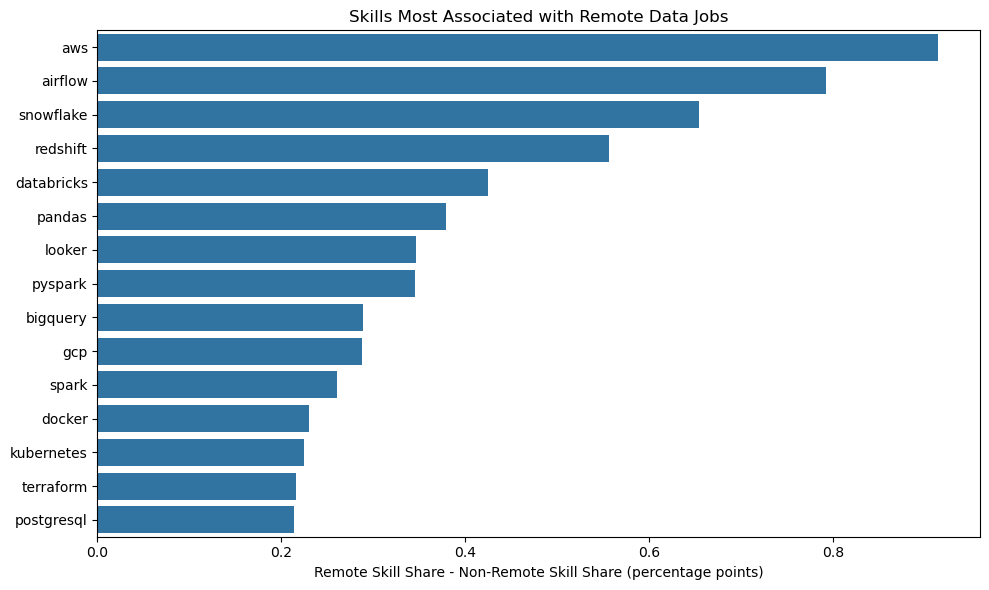

In [36]:
plt.figure(figsize=(10, 6))

plot_data = top_remote_skills.sort_values("difference",ascending=False)

sns.barplot(data=plot_data,x="difference",y=plot_data.index,orient="h")

plt.title("Skills Most Associated with Remote Data Jobs")
plt.xlabel("Remote Skill Share - Non-Remote Skill Share (percentage points)")
plt.ylabel("")
plt.tight_layout()
plt.show()